Esse desafio representa algo

In [69]:
#Imports

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter

%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="Set2",
    font_scale=1.05,
)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

STATUS_PALETTE = {
    "PASS": "#2E7D32",
    "FAIL": "#C62828",
    "REWORK": "#F9A825",
    "SCRAP": "#6A1B9A",
}

In [70]:
dataset = pd.read_excel('../Data/recording_test_setupbox.xlsx')

In [71]:
dataset.head()

,timestamp,date,time,shift,line,station,jig_id,operator,model,sku,wifi_band,has_bluetooth,has_cable,firmware_version,serial_number,mac_address,api_key,attempt,fw_download_ok,fw_download_cycle_s,fw_download_md5,bootloader_ok,bootloader_cycle_s,bootloader_md5,kernel_ok,kernel_cycle_s,kernel_md5,rootfs_ok,rootfs_cycle_s,rootfs_md5,secure_boot_ok,secure_boot_cycle_s,secure_boot_md5,mac_write_ok,mac_write_cycle_s,mac_write_md5,wifi_cal_ok,wifi_cal_cycle_s,wifi_cal_md5,bluetooth_ok,bluetooth_cycle_s,bluetooth_md5,cable_scan_ok,cable_scan_cycle_s,cable_scan_md5,hdmi_edid_ok,hdmi_edid_cycle_s,hdmi_edid_md5,dvb_tuner_ok,dvb_tuner_cycle_s,dvb_tuner_md5,drm_keys_ok,drm_keys_cycle_s,drm_keys_md5,final_check_ok,final_check_cycle_s,final_check_md5,cable_channels_found,total_cycle_s,result,failed_step,error_code,disposition
0,2022-09-12 06:00:06,2022-09-12,06:00:06,A,L2,L2-ST1,JIG-L2-ST1-2,OP-L2-A2,STB-300,LG-STB-300-5BC3,5GHz,True,True,v4.1.2,SN300220912083468,AC:5A:14:FB:E9:2B,RKEY-05B595FC92,1,True,12.80,8f9c832283bc6fa931da2c68e66da06c,True,7.60,e5e889166685aae9ea816fbd4b52e319,True,27.70,d0af4a614682e7bee95182bec5477298,True,38.40,630aee2328d502b6a8342c49610f3438,True,6.60,52bce2e22e945dc897f72eb4951871d5,True,3.80,f96ef125d029674df8000b867fa45c1a,True,33.30,8dd4ec9223c6b2684350790a6962dd38,1.00,15.60,27b5b9be5427a5a3b0b35e96df4330bd,1.00,35.10,21b28496b3d5e5389f4837847c2babe7,True,7.70,bebe4eee67d261bf493caeabd88b676f,True,18.30,92434477b026a09bf82617fda8edfe1c,True,10.10,8a8d71ffe52ed418e18205e1b08ffe99,True,5.20,7d761ebaf0435d3a4145fba0f02e32df,124.00,222.20,PASS,NaN,NaN,PASS
1,2022-09-12 06:00:07,2022-09-12,06:00:07,A,L1,L1-ST1,JIG-L1-ST1-1,OP-L1-A2,STB-100,LG-STB-100-2401,2.4GHz,False,False,v4.1.2,SN100220912073344,AC:5A:14:67:01:4C,RKEY-1AA670E63C,1,True,9.90,0d9346909082cbf9be11d3b7d4f2dc6c,True,8.80,f4d35c18a8c9a087421007f6b127780b,True,23.90,775e499985711c57608ac7ca210cc7e6,True,41.50,29329042173e587145f6e319f5481a31,True,6.00,19711710751177200ed1e3623ea6cb87,True,3.70,51bdcaad241d88e4c20069e85544c526,True,26.80,7c5ae2c9ee045a955dbf956a22b20165,NaN,NaN,NaN,NaN,NaN,NaN,True,7.20,1d45998b38268cadb47559c03e2dd0ef,True,15.80,91f9285bc19f6bf39fb8e01da1dc948e,True,8.90,a41d8f6bc155e6fbc73a07596c1556a2,True,4.50,0b308b6e810da8624459a91eb154c4e7,NaN,157.00,PASS,NaN,NaN,PASS
2,2022-09-12 06:00:41,2022-09-12,06:00:41,A,L2,L2-ST2,JIG-L2-ST2-2,OP-L2-A1,STB-300,LG-STB-300-5BC3,5GHz,True,True,v4.1.2,SN300220912073087,AC:5A:14:DB:76:1E,RKEY-05B595FC92,1,True,11.90,8f9c832283bc6fa931da2c68e66da06c,True,8.20,e5e889166685aae9ea816fbd4b52e319,True,25.00,d0af4a614682e7bee95182bec5477298,True,39.30,630aee2328d502b6a8342c49610f3438,True,6.50,52bce2e22e945dc897f72eb4951871d5,True,4.10,f96ef125d029674df8000b867fa45c1a,True,27.20,8dd4ec9223c6b2684350790a6962dd38,1.00,15.10,27b5b9be5427a5a3b0b35e96df4330bd,1.00,34.70,21b28496b3d5e5389f4837847c2babe7,True,8.40,bebe4eee67d261bf493caeabd88b676f,True,18.10,92434477b026a09bf82617fda8edfe1c,True,8.10,8a8d71ffe52ed418e18205e1b08ffe99,True,5.00,7d761ebaf0435d3a4145fba0f02e32df,126.00,211.60,PASS,NaN,NaN,PASS
3,2022-09-12 06:01:00,2022-09-12,06:01:00,A,L3,L3-ST2,JIG-L3-ST2-1,OP-L3-A2,STB-200,LG-STB-200-5C02,5GHz,False,True,v4.1.2,SN200220912078449,AC:5A:14:69:DD:B6,RKEY-1999061AD6,1,True,13.00,6050b8067d8bc1b16e6be2a078bc37ae,True,7.80,8f5d6101ddfaa62ae36d609073bc6129,True,24.20,0ef0c57946f8050913763c42d10ef2d9,True,38.10,c0679c6229a1372eab671da68f8dca30,True,5.60,3fb781d5d811a31931c68de2cd0e503c,True,3.80,431535d30c8c835c83975a7504fd5fcd,True,32.80,2e2714ad8c8808b8586f6505c5a23169,NaN,NaN,NaN,1.00,31.70,9370d8768535fa77c959078d8ccd7379,True,8.10,f89660499ce56b81f0a4ff767fe2637c,True,16.00,858037ddc1424fcb24cb85aa5028c778,True,9.70,d5efb1054f9129510bb384635bcef647,True,5.10,ff6e7d9b01c0fc8635391957a783a2a9,177.00,195.90,PASS,NaN,NaN,PASS
4,2022-09-12 06:01:14,2022-09-12,06:01:14,A,L4,L4-ST1,JIG-L4-ST1-1,OP-L4-A1,STB-400,LG-STB-400-5BC4,5GHz,True,True,v4.1.2,SN400220912079140,AC:5A:14:65:6C:6D,RKEY-2742E4DF18,1,T

In [72]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 17844 entries, 0 to 17843
Data columns (total 63 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             17844 non-null  str    
 1   date                  17844 non-null  str    
 2   time                  17844 non-null  str    
 3   shift                 17844 non-null  str    
 4   line                  17844 non-null  str    
 5   station               17844 non-null  str    
 6   jig_id                17844 non-null  str    
 7   operator              17844 non-null  str    
 8   model                 17844 non-null  str    
 9   sku                   17844 non-null  str    
 10  wifi_band             17844 non-null  str    
 11  has_bluetooth         17844 non-null  bool   
 12  has_cable             17844 non-null  bool   
 13  firmware_version      17844 non-null  str    
 14  serial_number         17844 non-null  str    
 15  mac_address           17844 no

Estatística Descritiva e Limpeza

In [73]:
dataset.describe()

,attempt,fw_download_cycle_s,bootloader_cycle_s,kernel_cycle_s,rootfs_cycle_s,secure_boot_cycle_s,mac_write_cycle_s,wifi_cal_cycle_s,bluetooth_ok,bluetooth_cycle_s,cable_scan_ok,cable_scan_cycle_s,hdmi_edid_cycle_s,dvb_tuner_cycle_s,drm_keys_cycle_s,final_check_cycle_s,cable_channels_found,total_cycle_s
count,"17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","7,026.00","7,026.00","12,263.00","12,263.00","17,844.00","17,844.00","17,844.00","17,844.00","12,263.00","17,844.00"
mean,1.10,12.16,8.08,26.44,40.40,6.07,4.04,30.97,0.99,16.19,0.99,35.32,8.11,18.26,10.16,5.09,151.85,200.42
std,0.30,2.91,1.68,6.68,8.50,1.28,0.82,8.03,0.08,3.53,0.09,7.17,1.98,4.44,2.62,1.41,21.74,27.31
min,1.00,8.00,5.30,16.80,27.70,4.00,2.70,20.80,0.00,11.40,0.00,24.80,5.10,12.40,6.50,3.40,0.00,148.60
25%,1.00,11.30,7.60,24.60,37.80,5.70,3.80,28.40,1.00,15.10,1.00,33.00,7.60,17.00,9.50,4.70,136.00,172.00
50%,1.00,12.00,8.00,26.00,40.00,6.00,4.00,30.10,1.00,16.00,1.00,35.00,8.00,18.00,10.00,5.00,153.00,204.70
75%,1.00,12.60,8.40,27.40,42.20,6.30,4.20,31.80,1.00,16.90,1.00,36.90,8.40,19.00,10.50,5.30,169.00,217.30
max,2.00,83.10,49.80,164.70,262.30,34.70,23.30,193.80,1.00,102.40,1.00,225.90,53.80,124.40,66.10,34.10,185.00,444.30


In [74]:
#Verificando se existem valores ausentes

dataset.isnull().sum()

timestamp                   0
date                        0
time                        0
shift                       0
line                        0
station                     0
jig_id                      0
operator                    0
model                       0
sku                         0
wifi_band                   0
has_bluetooth               0
has_cable                   0
firmware_version            0
serial_number               0
mac_address                 0
api_key                     0
attempt                     0
fw_download_ok              0
fw_download_cycle_s         0
fw_download_md5             0
bootloader_ok               0
bootloader_cycle_s          0
bootloader_md5              0
kernel_ok                   0
kernel_cycle_s              0
kernel_md5                  0
rootfs_ok                   0
rootfs_cycle_s              0
rootfs_md5                  0
secure_boot_ok              0
secure_boot_cycle_s         0
secure_boot_md5             0
mac_write_

Existem dados faltando para duas colunas, ambas equivalentes, But Why?

In [75]:
dataset.select_dtypes(include=['str']).nunique()

timestamp           16965
date                    3
time                15366
shift                   2
line                    4
station                 8
jig_id                 16
operator               16
model                   4
sku                     4
wifi_band               2
firmware_version        2
serial_number       16115
mac_address         16066
api_key                12
fw_download_md5       247
bootloader_md5         66
kernel_md5             91
rootfs_md5            636
secure_boot_md5        82
mac_write_md5          77
wifi_cal_md5          111
bluetooth_md5          45
cable_scan_md5        114
hdmi_edid_md5          89
dvb_tuner_md5          96
drm_keys_md5          703
final_check_md5        89
result                  2
failed_step            13
error_code             11
disposition             3
dtype: int64

As colunas time, serial number e mac adress possuem muitos valores unicos, possivlmente o fenomeno representado poder ser representado temporalmente

Variaveis categoricas com algum valor para analise: shift, line, station, model, sku, wifi_band, firmware_version, result, disposition. (Usar graficos de contagem)

Sobre o processo em si, Existem 16 Operadores e 16 dispositivos de testes (Esses troços de "jigs") operando o sistema, e sao pelo menos 13 ETAPAS de falha mapeadas.

Variaveis de interesse pra entender o processo: jig_id, operador, api_key, failed_step, error_code

Variavesi dos testes: roottfs_md5, fw_download_md5, cable_scan_md5 - guardam as configuracoes de hardwware testadas de forma unica (hashes).

# EDA

### Entendendo a concetraçao de falhas

### Distribuição de Pareto

Objetivo: identificar os poucos defeitos que concentram a maior parte das falhas e priorizar o que investigar primeiro.

In [76]:
failures = dataset.loc[dataset["result"].eq("FAIL")].copy()

print(f"Total de tentativas: {len(dataset):,}")
print(f"Total de falhas: {len(failures):,}")
print(f"Taxa de falha: {len(failures) / len(dataset):.2%}")

Total de tentativas: 17,844
Total de falhas: 2,296
Taxa de falha: 12.87%


In [77]:
def build_pareto(df, column):
    pareto = (
        df[column]
        .dropna()
        .value_counts()
        .rename_axis(column)
        .reset_index(name="count")
    )
    pareto["pct"] = pareto["count"] / pareto["count"].sum()
    pareto["cum_pct"] = pareto["pct"].cumsum()
    return pareto


def plot_pareto(df, column, title, ax):
    pareto = build_pareto(df, column)

    sns.barplot(
        data=pareto,
        x=column,
        y="count",
        ax=ax,
        color="#4C78A8",
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Quantidade de falhas")
    ax.tick_params(axis="x", rotation=45)
    ax.bar_label(ax.containers[0], padding=3, fontsize=8)

    ax2 = ax.twinx()
    ax2.plot(
        pareto[column],
        pareto["cum_pct"] * 100,
        color="#C62828",
        marker="o",
        linewidth=2,
    )
    ax2.axhline(80, color="#616161", linestyle="--", linewidth=1)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel("Percentual acumulado")
    ax2.yaxis.set_major_formatter(PercentFormatter())

    return pareto

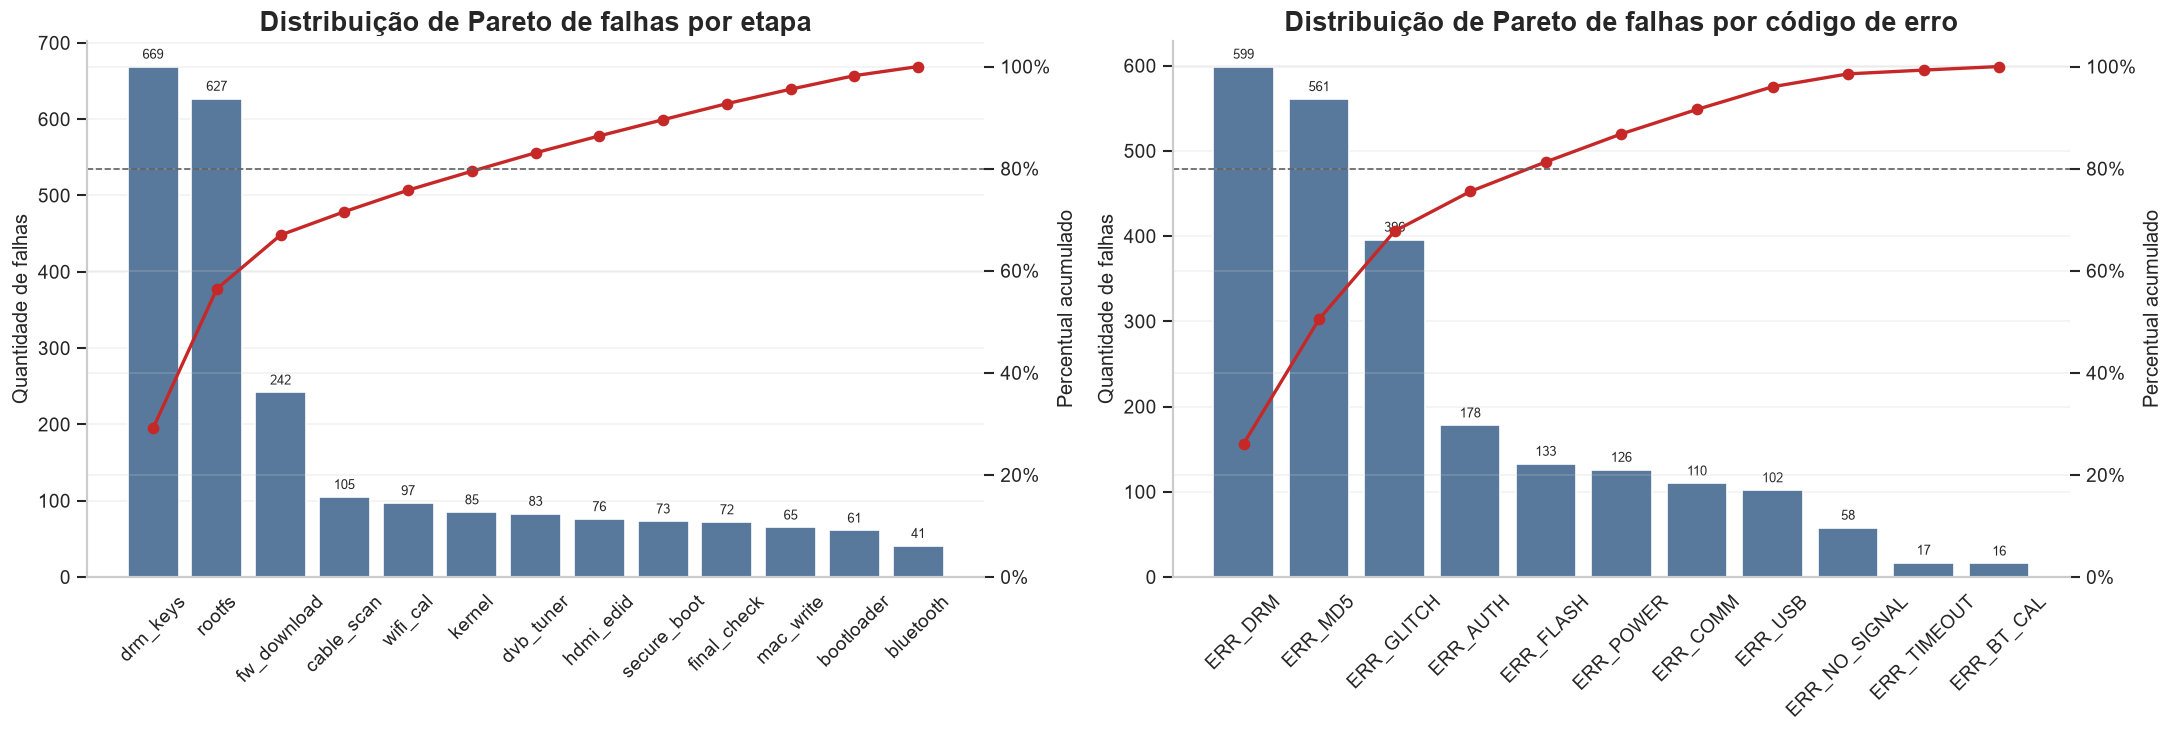

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

pareto_failed_step = plot_pareto(
    failures,
    "failed_step",
    "Distribuição de Pareto de falhas por etapa",
    axes[0],
)

pareto_error_code = plot_pareto(
    failures,
    "error_code",
    "Distribuição de Pareto de falhas por código de erro",
    axes[1],
)

plt.show()

In [79]:
pareto_failed_step_display = pareto_failed_step.copy()
pareto_failed_step_display["pct"] = (pareto_failed_step_display["pct"] * 100).map("{:.2f}%".format)
pareto_failed_step_display["cum_pct"] = (pareto_failed_step_display["cum_pct"] * 100).map("{:.2f}%".format)

pareto_error_code_display = pareto_error_code.copy()
pareto_error_code_display["pct"] = (pareto_error_code_display["pct"] * 100).map("{:.2f}%".format)
pareto_error_code_display["cum_pct"] = (pareto_error_code_display["cum_pct"] * 100).map("{:.2f}%".format)

display(pareto_failed_step_display)
display(pareto_error_code_display)

,failed_step,count,pct,cum_pct
0,drm_keys,669,29.14%,29.14%
1,rootfs,627,27.31%,56.45%
2,fw_download,242,10.54%,66.99%
3,cable_scan,105,4.57%,71.56%
4,wifi_cal,97,4.22%,75.78%
5,kernel,85,3.70%,79.49%
6,dvb_tuner,83,3.61%,83.10%
7,hdmi_edid,76,3.31%,86.41%
8,secure_boot,73,3.18%,89.59%
9,final_check,72,3.14%,92.73%


,error_code,count,pct,cum_pct
0,ERR_DRM,599,26.09%,26.09%
1,ERR_MD5,561,24.43%,50.52%
2,ERR_GLITCH,396,17.25%,67.77%
3,ERR_AUTH,178,7.75%,75.52%
4,ERR_FLASH,133,5.79%,81.32%
5,ERR_POWER,126,5.49%,86.80%
6,ERR_COMM,110,4.79%,91.59%
7,ERR_USB,102,4.44%,96.04%
8,ERR_NO_SIGNAL,58,2.53%,98.56%
9,ERR_TIMEOUT,17,0.74%,99.30%


12% das ocorrencias sao falhas, destas, a maior parte de concentra em erros de drm_keys com 29,14% desses erros, rootfs representa 27,31% dos erros, fw_download 10,54%. Esses 3 sozinhos representam 66,99% de todas as falhas, 2/3 dos defeitos registrados. Ou seja, esses 3 tipos de erros devem ser os primeiros a serem solucionados.

No caso do codigo de erro, ERR_DRM representa 26,09%, ERR_MD5 representa 24,43% dos erros e ERR_Glith representa 17,25%. Somados eles tambem sao quase 2/3 desses erros. Resumidanemente, a investigacao tem que correr primeiro por rm_keys/ERR_DRM, rootfs/ERR_MD5 e fw_download/ERR_AUTH, pois esses grupos explicam a maior parte dos defeitos e provavelmente indicam problemas sistemáticos no processo em sí.